# Sequential design for small samples

The regime where Bayesian optimization matters most: when every evaluation is precious - a wet-lab assay, a fabricated material, a multi-day model training, a field trial. The whole game is sample efficiency: reaching a good answer in tens of evaluations, not thousands. You'll measure that efficiency, and meet the two interfaces for real experiments: the ask-tell loop (a human/lab in the loop) and batch proposals (several experiments run in parallel).


## Information gain and the value of acting sequentially

When each experiment is precious, the question is which point reduces uncertainty the most. The natural
objective is information gain, the reduction in the entropy of the unknown (the optimum's location, or
the function itself) from observing a candidate.

Definition (information gain). For a candidate set $A$ of points with outcomes $y_A$, the information gain
about the target $\theta$ is $I(\theta; y_A)=H(\theta)-H(\theta\mid y_A)$. Sequential design picks the
next point greedily to maximize the one-step information gain; batch design picks a set at once.

Theorem (submodularity and the greedy guarantee; Nemhauser-Wolsey-Fisher). Mutual information
$A\mapsto I(\theta;y_A)$ is monotone and submodular (diminishing returns: adding a point helps less when
more points are already chosen). For maximizing a monotone submodular function under a cardinality
constraint, the greedy algorithm achieves at least $1-1/e\approx 0.63$ of the optimal value.

Consequence. Myopic, one-point-at-a-time selection (greedy EI or greedy information gain) is not merely a
heuristic; it carries a constant-factor optimality guarantee against the best non-myopic batch. This
justifies the ask-tell loop used in this notebook.

Counterexample (a naive batch wastes evaluations). Proposing a batch by simply taking the $q$ points with
the highest single-point acquisition selects $q$ near-duplicates clustered at the current best, so the
batch carries little more information than one evaluation. Diversity must be enforced, by penalizing
points near already-selected ones (local penalization) or by a repulsive determinantal-point-process or
$q$-EI objective, which is why the batch proposals in this notebook are spread out rather than stacked.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.doe import minimize, random_design, latin_hypercube, propose_batch, BayesianOptimizer
rng = np.random.RandomState(0)

## 1. Sample efficiency is the whole point

When data is cheap you can grid-search or random-search to your heart's content. When each point costs a day and a thousand dollars, you have maybe 20-40 shots. We compare three strategies on a fixed tiny budget - random search, a one-shot Latin-hypercube design (best of the batch), and sequential Bayesian optimization - by best-value-found vs evaluations, averaged over several random seeds to be fair.


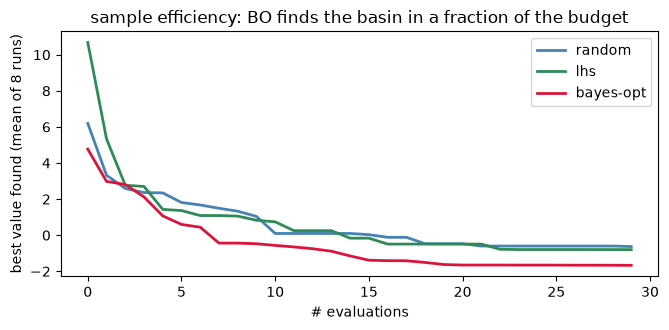

after 30 evals  random: -0.629  lhs: -0.800  bayes-opt: -1.671


In [2]:
def objective(p):                       # a 2-D problem with one narrow basin (hard to hit by luck)
    x, y = p
    return float((x - 1.5) ** 2 + (y - 1.5) ** 2 + 2 * np.sin(4 * x) * np.sin(4 * y))
space = [(-2.0, 2.0), (-2.0, 2.0)]; budget = 30

def best_curve(strategy, seed):
    if strategy == 'random':
        ys = np.array([objective(p) for p in random_design(space, budget, seed=seed)])
    elif strategy == 'lhs':
        ys = np.array([objective(p) for p in latin_hypercube(space, budget, seed=seed)])
    else:
        ys = minimize(objective, space, n_init=5, n_iter=budget - 5, seed=seed).y
    return np.minimum.accumulate(ys)

curves = {s: np.mean([best_curve(s, k) for k in range(8)], axis=0)
          for s in ['random', 'lhs', 'bayes-opt']}
fig, ax = plt.subplots(figsize=(6.8, 3.4))
for s, c in zip(['random', 'lhs', 'bayes-opt'], ['steelblue', 'seagreen', 'crimson']):
    ax.plot(curves[s], color=c, lw=2, label=s)
ax.set_xlabel('# evaluations'); ax.set_ylabel('best value found (mean of 8 runs)'); ax.legend()
ax.set_title('sample efficiency: BO finds the basin in a fraction of the budget')
plt.tight_layout(); plt.show()
print('after %d evals  random: %.3f  lhs: %.3f  bayes-opt: %.3f' %
      (budget, curves['random'][-1], curves['lhs'][-1], curves['bayes-opt'][-1]))

## 2. The ask-tell loop: a human (or lab) in the loop

In a real experiment there is no `objective` function to call - you run the assay and report the result. `BayesianOptimizer` exposes exactly that: `ask()` proposes the next input, you perform the experiment, and `tell(x, y)` records the outcome. The optimizer carries the GP state between steps. Here we drive it manually (standing in for the lab) for a few rounds.


In [3]:
opt = BayesianOptimizer(space, seed=1, n_init=4)
for step in range(12):
    x = opt.ask()                       # the optimizer proposes an experiment
    y = objective(x)                    # <-- in practice: run the assay / training / trial and read the result
    opt.tell(x, y)                      # report it back
print('after %d ask/tell rounds: best x = %s  best y = %.3f' %
      (opt.n_observations, np.round(opt.best.best_x, 2), opt.best.best_y))

after 12 ask/tell rounds: best x = [1.33 1.69]  best y = -0.714


## 3. Batch proposals: parallel experiments

Often you can run several experiments at once (a 96-well plate, a cluster of training jobs). Asking for the single best point wastes that parallelism - and proposing the same point several times is pointless. `propose_batch` returns $q$ diverse points (via the kriging-believer heuristic: hallucinate the surrogate's prediction at each chosen point so the next is pushed elsewhere). We propose a batch of 5 and see they spread out rather than clustering.


proposed batch of 5 (note the spread, not 5 copies of one point):
[[ 1.99 -1.54]
 [ 2.   -0.09]
 [ 1.98  0.2 ]
 [ 1.98 -0.35]
 [ 1.98  0.14]]


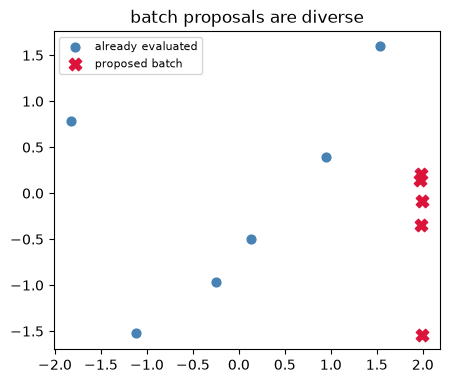

In [4]:
x0 = latin_hypercube(space, 6, seed=2); y0 = np.array([objective(p) for p in x0])
batch = propose_batch(x0, y0, space, q=5, seed=3)
print('proposed batch of %d (note the spread, not 5 copies of one point):' % len(batch))
print(np.round(batch, 2))
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(x0[:, 0], x0[:, 1], s=40, color='steelblue', label='already evaluated')
ax.scatter(batch[:, 0], batch[:, 1], s=80, color='crimson', marker='X', label='proposed batch')
ax.set_title('batch proposals are diverse'); ax.legend(fontsize=8); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Batch vs sequential at a fixed budget

Parallel experiments are convenient but cost sample efficiency: a purely sequential loop uses every result before choosing the next point, while a batch must commit $q$ points knowing less. We compare 20 sequential evaluations against 4 batches of 5 (`propose_batch`) on the same objective and budget.


In [5]:
seq_best = minimize(objective, space, n_init=5, n_iter=15, seed=1).best_y     # 20 sequential evals
x = latin_hypercube(space, 5, seed=1); y = np.array([objective(p) for p in x])
for _ in range(3):                                                            # 3 more batches of 5 -> 20 total
    b = propose_batch(x, y, space, q=5, seed=1)
    x = np.vstack([x, b]); y = np.append(y, [objective(p) for p in b])
print('best at 20 evaluations   sequential: %.3f   batch (4x5): %.3f' % (seq_best, y.min()))
print('sequential is usually at least as good per evaluation; batching trades efficiency for wall-clock.')

best at 20 evaluations   sequential: -1.661   batch (4x5): 0.235
sequential is usually at least as good per evaluation; batching trades efficiency for wall-clock.


## References

- Settles, B. (2009). Active Learning Literature Survey (https://minds.wisconsin.edu/handle/1793/60660). Computer Sciences Tech. Report 1648, Univ. Wisconsin-Madison.
- Gramacy, R. B. (2020). Surrogates: Gaussian Process Modeling, Design, and Optimization for the Applied Sciences (https://bobby.gramacy.com/surrogates/). CRC Press.
- Ginsbourger, D., Le Riche, R. & Carraro, L. (2010). Kriging is well-suited to parallelize optimization (https://doi.org/10.1007/978-3-642-10701-6_6). In Computational Intelligence in Expensive Optimization Problems. - the kriging-believer batch heuristic.
- Frazier, P. I. (2018). A tutorial on Bayesian optimization (https://arxiv.org/abs/1807.02811). arXiv:1807.02811.
- Greenhill, S. et al. (2020). Bayesian optimization for adaptive experimental design: a review (https://doi.org/10.1109/ACCESS.2020.2966228). IEEE Access 8, 13937-13948.


## Exercises and extensions

1. Budget-curve study. Plot final best-found vs total budget (5, 10, 20, 50, 100) for BO vs random vs one-shot LHS, averaged over seeds with error bars. Quantify the budget regime where BO's advantage is decisive and where it vanishes (large budgets) (Frazier).
2. Noisy, costly evaluations. Add observation noise and a heterogeneous evaluation cost; implement a cost-aware acquisition (EI per unit cost) and show it beats plain EI when cheap-but-informative points exist (Snoek et al.; Gramacy).
3. Batch vs sequential. For a fixed total of 20 evaluations, compare 4 batches of 5 (`propose_batch`, kriging-believer, Ginsbourger et al.) against 20 sequential steps; measure the sample-efficiency cost of parallelism and when it is worth paying.
4. Active learning for a surrogate. Instead of optimizing, learn a global surrogate: pick points by maximum predictive variance (active learning, Settles) and compare the resulting model's accuracy to a space-filling design at equal budget.
